In [58]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from utils import *
import sys
from astropy.io import fits
import cloud_model_torch as cmt 
import matplotlib

In [59]:
# Default matplotlib settings
matplotlib.rcParams['image.interpolation'] = 'nearest'

In [60]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
# Add after imports
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [62]:
# ====================================================================
def optimization(optimizer,niterations,parameters,model, xl, img):
    """
    This function performs the optimization of the parameters of the model.
    """
    # Move data to GPU if not already there:
    if not isinstance(img, torch.Tensor):
        img = torch.from_numpy(np.array(img.astype(np.float32)))
    if img.device != parameters.device:
        img = img.to(device)
    
    from tqdm import trange
    t = trange(niterations, leave=True)
    for loop in t:
        optimizer.zero_grad()        #reset gradients
        img_syn = cloud_model(xl, parameters)
        img_syn = img_syn.reshape(img.shape[0], img.shape[1], -1)
        chi2loss = torch.mean(torch.sum((img - img_syn)**2.0))
        
        reguloss = chi2loss*0.0
        #reguloss += 1e1*regu2(parameters, 0,img)
        #reguloss += 1e1*regu2(parameters, 1,img) 
        #reguloss += 1e-1*regu2(parameters, 2,img)
        #reguloss += 5e-2*regu2(parameters, 3,img)
        #reguloss += 5e-2*regu2(parameters, 4,img)
        #reguloss += 1e1*regu2(parameters, 5,img)
        #reguloss += 1e2*regu2(parameters, 6,img)
        #reguloss += 2e-2*regu2(parameters, 8,img)

        loss = chi2loss + reguloss

        loss.backward()              #calculate gradients
        optimizer.step()             #step fordward

        t.set_postfix({'loss': loss.item(), 'chi2loss': chi2loss.item(), 'reguloss': reguloss.item()})

    parameters = parameters.reshape(img.shape[0],img.shape[1],-1)
    parameters = parameters.detach().cpu().numpy()
    img_syn = img_syn.detach().cpu().numpy()
    return parameters, img_syn


In [63]:
# ========================================================================================================
def cloud_model(x, params):
    #return cmt.model_synth(x, params)
    return cmt.model_synth_2clouds(x, params)


In [64]:
# ================================================================================================================
# Readind the data:

# data_filename = "/mn/stornext/d20/RoCS/carlosjd/colabs/ivan/MIHI/cloudinv_mihi/data/mihi_data.fits"
# data_filename = "/home/milic/data/scratch/mihi_data.fits"
data_filename = "/home/milic/data/img_fit.210800..211599.00.00.lr0250.cube.fits"

tofit = fits.open(data_filename)[0].data[15:-15, 15:-15,0,100:500]
Iqs = np.mean(tofit[:,:,-20])
print("info::normalizing the input data to the value: ", Iqs)
tofit /= Iqs
tofit = tofit.astype(float)
print("info::the input observations have the shape:", tofit.shape)
xl = fits.open(data_filename)[1].data[100:500]
ll0 = np.asarray([np.mean(xl)])
xl = [xl,ll0]



# Transform data into pytorch object:
tofit_pt = torch.from_numpy(np.array(tofit.astype(np.float32))).to(device)


info::normalizing the input data to the value:  6.7399073
info::the input observations have the shape: (116, 130, 400)


In [83]:
# ================================================================================================================
# Defining the parameters of the model in the FOV:
pars = torch.ones(tofit.shape[0]*tofit.shape[1], 16, device=device) # (NX x NY) x NP cube

# Initialize the starting values:
pars[:,0] = 0.4 # S0
pars[:,1] = 0.85 # S1
pars[:,2] = 3.0 # eta in units if 1000s
pars[:,3] = 12.0 # los velocity
pars[:,4] = 10.0 # doppler width 
pars[:,5] = -2.0 # log a

# Cloud: 
pars[:,6] = 0.4 # S
pars[:,7] = 4.5 # tau
pars[:,8] = -2.0 # los velocity
pars[:,9] = 6.0 # Doppler width
pars[:,10] = -4.0 # log a

# Cloud: 
pars[:,11] = 0.1 # S
pars[:,12] = 1.0 # tau
pars[:,13] = 10.0 # los velocity
pars[:,14] = 5.0 # Doppler width
pars[:,15] = -5.0 # log a

pars.requires_grad = True


In [84]:
# Parameters:
print("info:: parameters:", torch.mean(pars, axis=(0)))

info:: parameters: tensor([ 0.4000,  0.8500,  3.0000, 12.0000, 10.0000, -2.0000,  0.4000,  4.5000,
        -2.0000,  6.0000, -4.0000,  0.1000,  1.0000, 10.0000,  5.0000, -5.0000],
       grad_fn=<MeanBackward1>)


In [ ]:
# ====================================================================
# Send all the info to the optimization module inside the utils.py file:
optimizer = torch.optim.Adam([pars], lr=1e-1)
niter = 100
mymodel = cloud_model # Model from the above
parameters, fit_spectra = optimization(optimizer=optimizer,niterations=niter,
                                        parameters=pars,model=mymodel,xl=xl,img=tofit)

chisq = np.sum((tofit - fit_spectra)**2.0, axis=2) / 400.0
print(np.mean(chisq[0,0]))


100%|██████████| 50/50 [02:06<00:00,  2.53s/it, loss=4.37e+5, chi2loss=4.37e+5, reguloss=0]

0.0011046948148939085


In [89]:
# Average the parameters for only print:
print("info::average parameters:", np.mean(parameters, axis=(0,1)))

info::average parameters: [ 1.1515478  -0.21180427  3.7562509   8.588884   10.450822   -1.1658491
  0.15366858  9.375047   -8.117884   10.655438    0.08345521  0.3845278
  0.9319022  11.547238    7.8159113  -3.0377307 ]


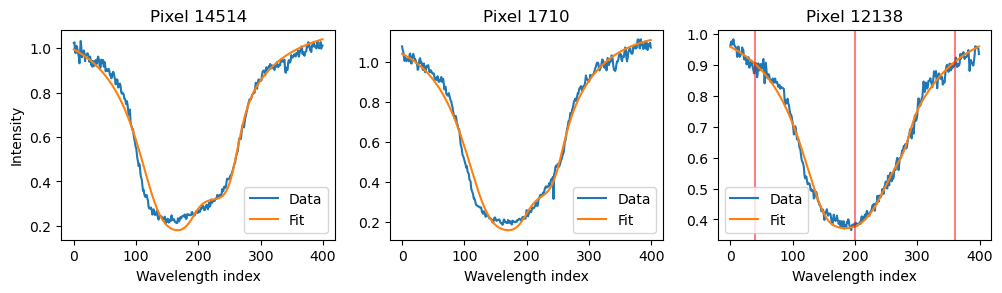

In [90]:
# Extract and compare 3 random pixels from the fit and the data:
np.random.seed(91)
idxs = np.random.randint(0, tofit.shape[0]*tofit.shape[1], size=3)
plt.figure(figsize=[12,6])
for j, idx in enumerate(idxs):
    plt.subplot(2, 3, j+1)
    plt.plot(tofit.reshape(-1, tofit_pt.shape[2])[idx], label='Data')
    plt.plot(fit_spectra.reshape(-1, fit_spectra.shape[2])[idx], label='Fit')
    plt.title(f"Pixel {idx}")
    plt.xlabel('Wavelength index')
    plt.legend()
    if j == 0:
        plt.ylabel('Intensity')
        
# Vertical lines at:
idxs_lambda = [int(0.1*tofit.shape[2]), int(0.5*tofit.shape[2]), int(0.9*tofit.shape[2])]
for idx_lambda in idxs_lambda:
    plt.axvline(x=idx_lambda, color='r', linestyle='-', label=f'Wavelength {idx_lambda}', alpha=0.5)

plt.savefig('mihi_random_spectra_coupled.png', bbox_inches='tight', dpi=300)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=[10, 6], sharex=True, sharey=True)
for j, idx in enumerate(idxs_lambda):
    ax_obs = axes[0, j]
    im_obs = ax_obs.imshow(tofit[:, :, idx].T, origin='lower', cmap='gray')
    ax_obs.set_title(f"Obs λ idx {idx}")
    fig.colorbar(im_obs, ax=ax_obs)
    ax_obs.scatter(idxs[j] % tofit.shape[1], idxs[j] // tofit.shape[1], color='red', marker='x', s=100)

    ax_fit = axes[1, j]
    im_fit = ax_fit.imshow(fit_spectra[:, :, idx].T, origin='lower', cmap='gray',
                          vmin=tofit_pt[:, :, idx].min(), vmax=tofit_pt[:, :, idx].max())
    ax_fit.set_title(f"Fit λ idx {idx}")
    fig.colorbar(im_fit, ax=ax_fit)
plt.tight_layout()
plt.savefig('mihi_fit_images_coupled.png', bbox_inches='tight', dpi=300)


In [ ]:
im = plt.imshow(np.log10(chisq).T, origin='lower', cmap='magma')
add_colorbar(im, label=r'$\log_{10}(\chi^2)$')

In [ ]:
labels = ['S0', 'S1', 'eta', 'los velocity', 'doppler width', 'log a',
          'S cloud', 'tau cloud', 'los velocity cloud', 'doppler width cloud',
          'log a cloud', 'S cloud2', 'tau cloud2', 'los velocity cloud2',
          'doppler width cloud2', 'log a cloud2']
fig, axes = plt.subplots(4, 4, figsize=[16, 14], sharex=True, sharey=True)
ax = axes.flatten()
for i in range(16):
    im = ax[i].imshow(parameters[:, :, i].T, origin='lower')
    ax[i].set_title(labels[i])
    fig.colorbar(im, ax=ax[i])
plt.tight_layout()

plt.savefig('mihi_parameters_coupled.png', bbox_inches='tight', dpi=300)
